In [35]:
import tifffile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import os
import pathlib
from scipy.ndimage import distance_transform_edt

import skimage
from skimage.feature import peak_local_max
from skimage import util,  restoration
from skimage.filters import threshold_otsu, threshold_isodata, threshold_li, threshold_minimum, threshold_mean, threshold_yen, threshold_multiotsu, threshold_triangle
from skimage.segmentation import clear_border, expand_labels, watershed
from skimage.measure import label, regionprops_table
from skimage.morphology import remove_small_holes, remove_small_objects, closing,  disk, dilation
from scipy.ndimage import distance_transform_edt
from scipy import ndimage as ndi
from skimage.filters import try_all_threshold
from skimage.filters import gaussian, median as median_filter, threshold_li, threshold_mean, threshold_triangle, threshold_yen
from skimage.measure import label, regionprops, regionprops_table
from skimage.morphology import closing, disk, square, erosion, remove_small_holes
from skimage.segmentation import watershed, expand_labels
from skimage.feature import peak_local_max
import warnings
warnings.filterwarnings("ignore")
import pathlib
from skimage.morphology import closing,  disk, dilation, erosion, ball
from skimage.measure import regionprops
from skimage.exposure import rescale_intensity
import contextlib
import joblib
from tqdm import tqdm
from joblib import Parallel, delayed
import matplotlib.gridspec as gridspec


In [36]:
test_image = tifffile.imread(r"Z:\Dorota_Avalon\cytokine array\cytokine array devices\c1\IM000252.Tif")

In [37]:
import skimage.measure as skm


def sort_props_book_order(props, row_tol_frac=0.5):
    """Sort regionprops left-to-right, top-to-bottom (reading order).

    Clusters centroids into rows using a tolerance derived from the
    median equivalent diameter, so small vertical jitter inside a row
    does not scramble the order.
    """
    if not props:
        return []
    diameters = [p.equivalent_diameter for p in props]
    tol = max(1.0, np.median(diameters) * row_tol_frac)

    by_y = sorted(props, key=lambda p: p.centroid[0])
    rows, current = [], [by_y[0]]
    for p in by_y[1:]:
        if p.centroid[0] - current[-1].centroid[0] <= tol:
            current.append(p)
        else:
            rows.append(current)
            current = [p]
    rows.append(current)

    ordered = []
    for row in rows:
        ordered.extend(sorted(row, key=lambda p: p.centroid[1]))
    return ordered


labelled_devices_raw = label(test_image > threshold_triangle(test_image))

# Keep only the 4 largest regions, reindex 1-4 L->R, T->B (reading order)
props_all = skm.regionprops(labelled_devices_raw)
top4 = sorted(props_all, key=lambda p: p.area, reverse=True)[:4]
top4_sorted = sort_props_book_order(top4)

label_map = np.zeros(labelled_devices_raw.max() + 1, dtype=labelled_devices_raw.dtype)
for new_label, prop in enumerate(top4_sorted, start=1):
    label_map[prop.label] = new_label
labelled_devices = label_map[labelled_devices_raw]


device 1: row spacing=0.077 offset=0.203 | col spacing=0.080 offset=0.208
device 2: row spacing=0.075 offset=0.180 | col spacing=0.082 offset=0.185
device 3: row spacing=0.078 offset=0.149 | col spacing=0.075 offset=0.232
device 4: row spacing=0.075 offset=0.220 | col spacing=0.072 offset=0.249


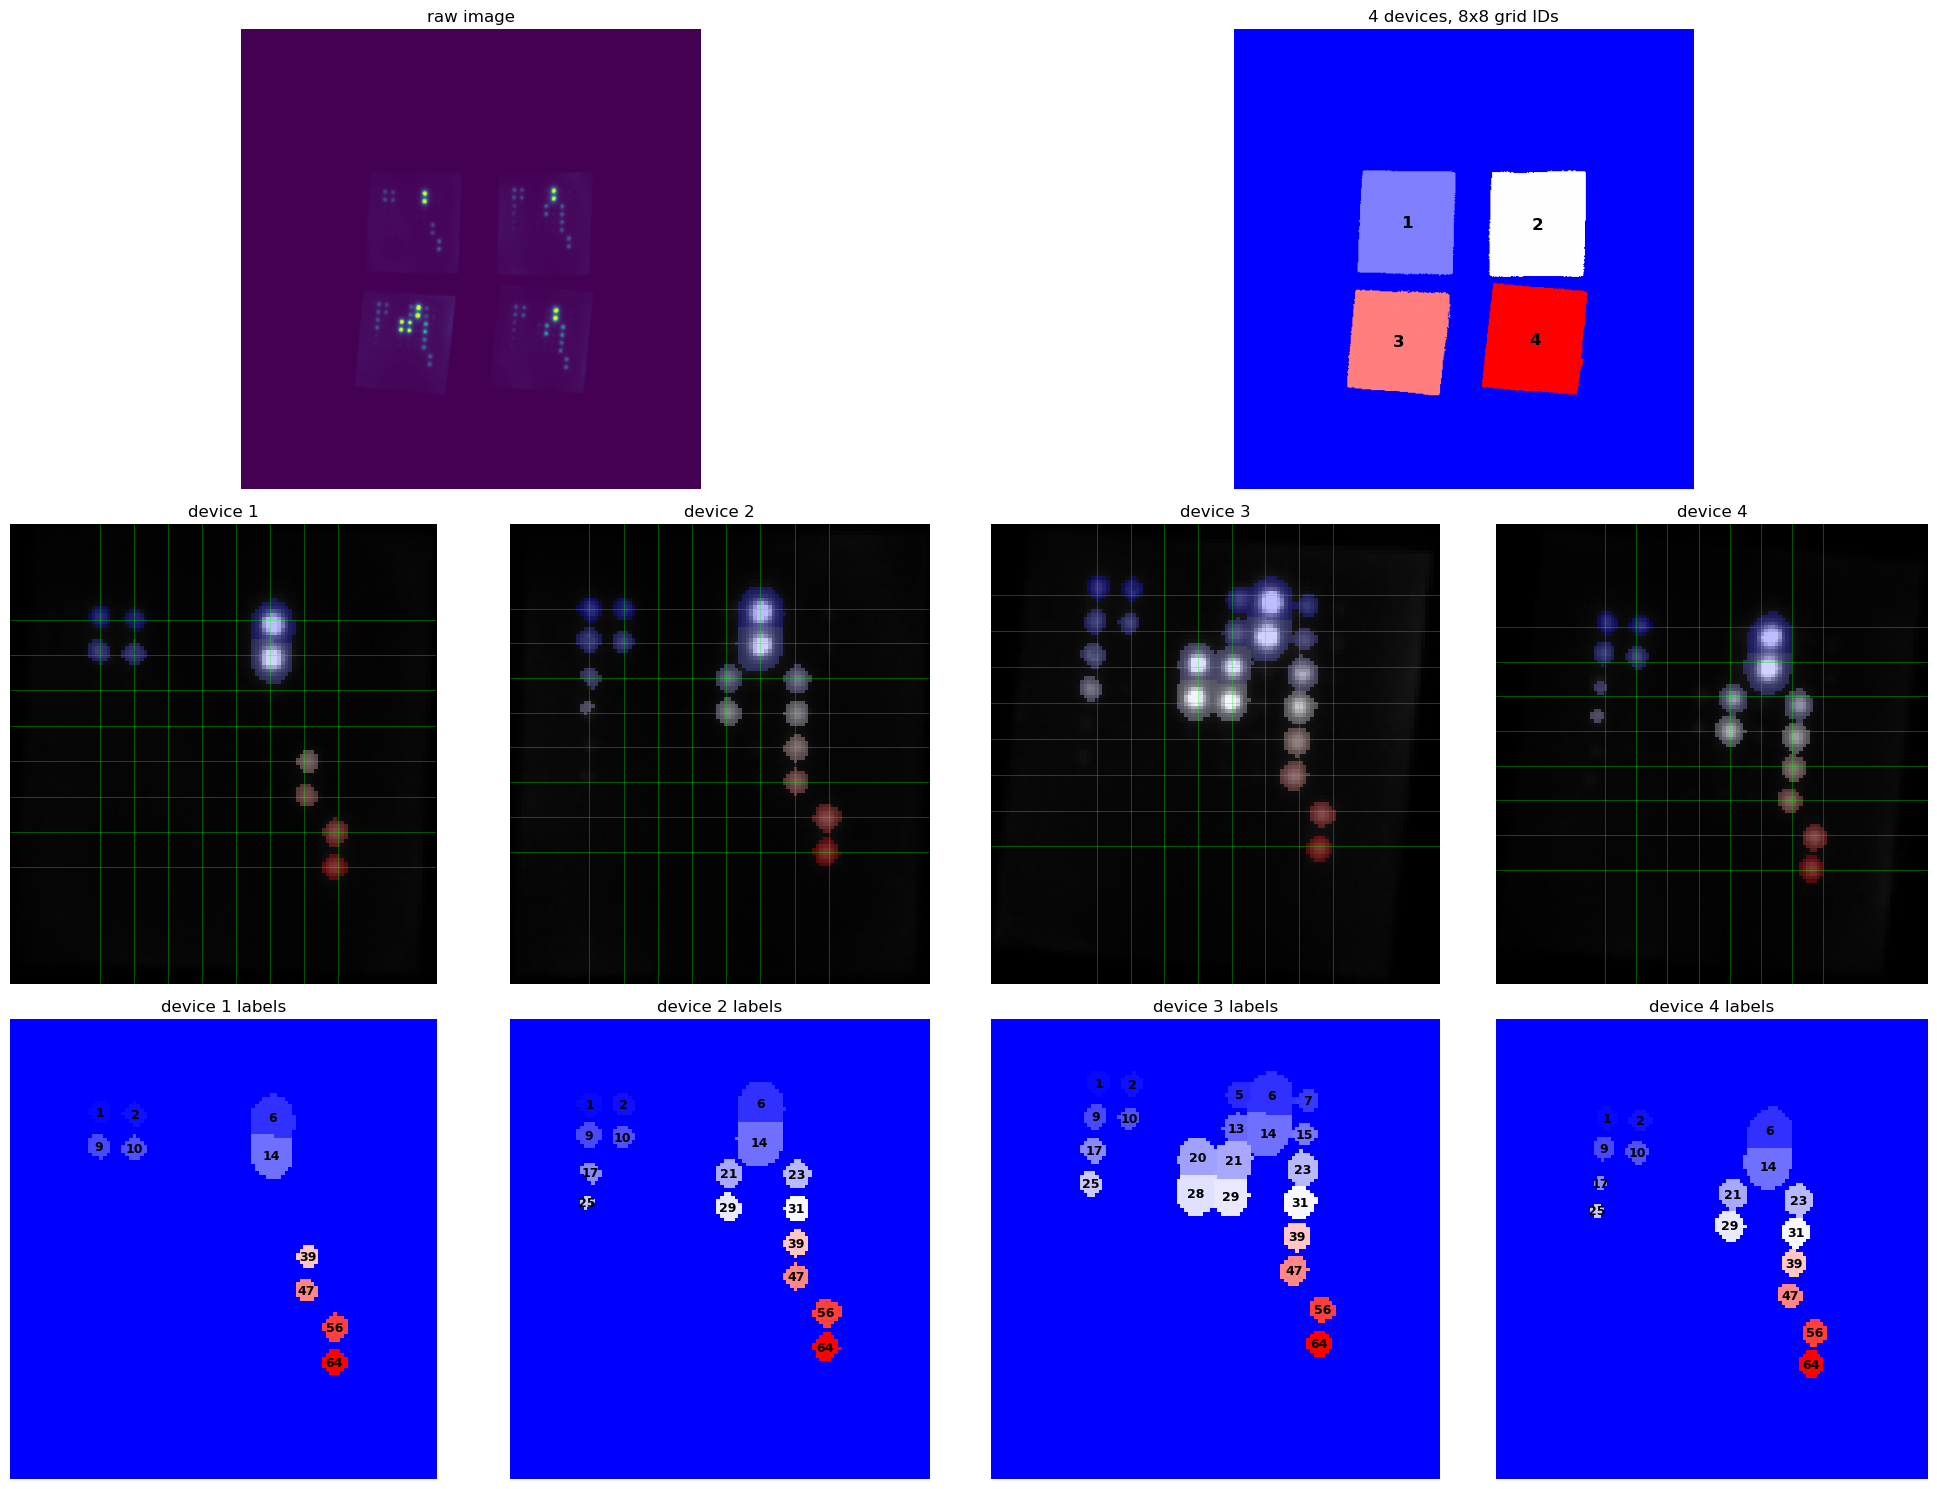

,device_id,circle_id,total_intensity
0,1,1,250100
1,1,2,207979
2,1,6,2610070
3,1,9,262057
4,1,10,228720
...,...,...,...
59,4,31,657602
60,4,39,425313
61,4,47,392738
62,4,56,417525


In [43]:
GRID = 8  # 8x8 grid (blanks allowed)


def segment_circles(crop):
    """Threshold + watershed circles within a device crop."""
    rescaled = rescale_intensity(crop.astype(float), out_range=(0, 255))
    circles = rescaled > threshold_li(rescaled)
    labelled = label(circles)
    coords = peak_local_max(rescaled, min_distance=4)
    markers = np.zeros(rescaled.shape, dtype=np.uint32)
    markers[tuple(np.round(coords).astype(int).T)] = np.arange(len(coords)) + 1
    seg = expand_labels(watershed(-rescaled, markers, mask=labelled > 0), distance=1)
    return seg, rescaled


def fit_uniform_grid(values, k, s_min, s_max, n_s=200, n_iter=20):
    """Fit k evenly-spaced grid positions o, o+s, ..., o+(k-1)s to 1-D `values`.

    Blanks are fine: each value snaps to its nearest grid index in 0..k-1 and we
    minimise the total squared residual over (s, o). Grid-search s, then refine
    (s, o) by least squares given current index assignments.
    """
    values = np.asarray(values, dtype=float)
    best = (np.inf, None, None)
    for s in np.linspace(s_min, s_max, n_s):
        o = float(values.min())
        for _ in range(n_iter):
            idx = np.clip(np.round((values - o) / s).astype(int), 0, k - 1)
            A = np.column_stack([np.ones_like(idx, dtype=float), idx.astype(float)])
            (o_new, s_new), *_ = np.linalg.lstsq(A, values, rcond=None)
            if abs(o_new - o) < 1e-6 and abs(s_new - s) < 1e-6:
                o, s = o_new, s_new
                break
            o, s = o_new, s_new
        idx = np.clip(np.round((values - o) / s).astype(int), 0, k - 1)
        resid = float(np.sum((values - (o + idx * s)) ** 2))
        if resid < best[0]:
            best = (resid, s, o)
    _, s, o = best
    return o + np.arange(k) * s, s, o


device_ids = [d for d in sorted(np.unique(labelled_devices)) if d != 0]
n = len(device_ids)

# --- Pass 1: segment each device and fit its OWN 8x8 grid ---
device_results = {}
for dev_id in device_ids:
    minr, minc, maxr, maxc = skm.regionprops((labelled_devices == dev_id).astype(int))[0].bbox
    crop = test_image[minr:maxr, minc:maxc]
    seg, rescaled = segment_circles(crop)
    H, W = seg.shape

    centroids = {p.label: (p.centroid[0] / H, p.centroid[1] / W) for p in skm.regionprops(seg)}
    ys = [v[0] for v in centroids.values()]
    xs = [v[1] for v in centroids.values()]

    row_centres, sy, oy = fit_uniform_grid(ys, GRID, s_min=0.06, s_max=0.16)
    col_centres, sx, ox = fit_uniform_grid(xs, GRID, s_min=0.06, s_max=0.16)
    print(f"device {dev_id}: row spacing={sy:.3f} offset={oy:.3f} | "
          f"col spacing={sx:.3f} offset={ox:.3f}")

    # Remap each circle to its (row, col) grid cell -> cell_id = row*8 + col + 1
    local_lmap = np.zeros(seg.max() + 1, dtype=np.int32)
    used = {}  # cell_id -> (local_id, distance)
    for local_id, (ly, lx) in centroids.items():
        r = int(np.clip(round((ly - oy) / sy), 0, GRID - 1))
        c = int(np.clip(round((lx - ox) / sx), 0, GRID - 1))
        cell_id = r * GRID + c + 1  # 1..64, always position A1 == 1
        dist = np.hypot(row_centres[r] - ly, col_centres[c] - lx)
        if cell_id in used and used[cell_id][1] <= dist:
            continue
        if cell_id in used:
            local_lmap[used[cell_id][0]] = 0
        used[cell_id] = (local_id, dist)
        local_lmap[local_id] = cell_id
    # Unmatched circles get fresh IDs above 64
    next_id = GRID * GRID + 1
    for local_id in centroids:
        if local_lmap[local_id] == 0:
            local_lmap[local_id] = next_id
            next_id += 1

    device_results[dev_id] = {
        "crop": crop, "rescaled": rescaled, "seg": local_lmap[seg],
        "row_centres": row_centres, "col_centres": col_centres,
    }

# --- Plot: 3-row figure ---
fig = plt.figure(figsize=(5 * n, 15))
gs = gridspec.GridSpec(3, n, figure=fig, height_ratios=[1, 1, 1])

ax_raw = fig.add_subplot(gs[0, : n // 2])
ax_raw.imshow(test_image)
ax_raw.set_title("raw image")
ax_raw.axis("off")

ax_dev = fig.add_subplot(gs[0, n // 2 :])
ax_dev.imshow(labelled_devices, cmap="bwr")
for prop in skm.regionprops(labelled_devices):
    cy, cx = prop.centroid
    ax_dev.text(cx, cy, str(prop.label), color="black", fontsize=12,
                ha="center", va="center", fontweight="bold")
ax_dev.set_title(f"{n} devices, {GRID}x{GRID} grid IDs")
ax_dev.axis("off")

records = []
for i, dev_id in enumerate(device_ids):
    res = device_results[dev_id]
    seg = res["seg"]
    H, W = seg.shape

    ax_overlay = fig.add_subplot(gs[1, i])
    ax_overlay.imshow(res["rescaled"], cmap="gray")
    ax_overlay.imshow(np.ma.masked_where(seg == 0, seg), cmap="bwr", alpha=0.3)
    for rc in res["row_centres"]:
        ax_overlay.axhline(rc * H, color="lime", lw=0.4, alpha=0.6)
    for cc in res["col_centres"]:
        ax_overlay.axvline(cc * W, color="lime", lw=0.4, alpha=0.6)
    ax_overlay.set_title(f"device {dev_id}")
    ax_overlay.axis("off")

    ax_lbl = fig.add_subplot(gs[2, i])
    ax_lbl.imshow(seg, cmap="bwr")
    for p in skm.regionprops(seg):
        cy, cx = p.centroid
        ax_lbl.text(cx, cy, str(p.label), color="black", fontsize=9,
                    ha="center", va="center", fontweight="bold")
    ax_lbl.set_title(f"device {dev_id} labels")
    ax_lbl.axis("off")

    pt = regionprops_table(seg, intensity_image=res["crop"],
                           properties=["label", "area", "mean_intensity"])
    df = pd.DataFrame(pt)
    df["device_id"] = dev_id
    df["circle_id"] = df["label"]
    df["total_intensity"] = (df["mean_intensity"] * df["area"]).astype(int)
    records.append(df[["device_id", "circle_id", "total_intensity"]])

plt.tight_layout()
plt.show()

df_circles = (pd.concat(records, ignore_index=True)
              .sort_values(["device_id", "circle_id"])
              .reset_index(drop=True))
df_circles
